# Alignment quality scoring with `score_alignment`

After aligning two spatial transcriptomics datasets, we need quantitative metrics
to evaluate how good the alignment is. This notebook demonstrates
`sq.experimental.tl.score_alignment` on a real cross-technology alignment:

- **MERFISH** (Allen Brain Cell Atlas, section 38): 120k cells, 550 genes
- **Xenium** (10x Genomics, fresh-frozen mouse brain): 131k cells, 248 genes
- **90 shared genes** for expression-based metrics

In [4]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import anndata as ad
import squidpy as sq

plt.rcParams["figure.figsize"] = (12, 5)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Load data

In [5]:
adata_merfish = ad.read_h5ad("data/merfish_section38.h5ad")
adata_xenium = ad.read_h5ad("data/xenium_mouse_brain.h5ad")

shared_genes = sorted(set(adata_merfish.var_names) & set(adata_xenium.var_names))

print(f"MERFISH:       {adata_merfish.n_obs} cells x {adata_merfish.n_vars} genes")
print(f"Xenium:        {adata_xenium.n_obs} cells x {adata_xenium.n_vars} genes")
print(f"Shared genes:  {len(shared_genes)}")
print(f"  Examples: {shared_genes[:10]}")

cm = adata_merfish.obsm["spatial"]
cx = adata_xenium.obsm["spatial"]
print(f"\nMERFISH spatial: x=[{cm[:,0].min():.1f}, {cm[:,0].max():.1f}], y=[{cm[:,1].min():.1f}, {cm[:,1].max():.1f}]")
print(f"Xenium spatial:  x=[{cx[:,0].min():.1f}, {cx[:,0].max():.1f}], y=[{cx[:,1].min():.1f}, {cx[:,1].max():.1f}]")

MERFISH:       120186 cells x 550 genes
Xenium:        130870 cells x 248 genes
Shared genes:  90
  Examples: ['Acta2', 'Adamts2', 'Adamtsl1', 'Angpt1', 'Aqp4', 'Arhgap25', 'Bcl11b', 'Calb1', 'Calb2', 'Car4']

MERFISH spatial: x=[0.5, 10.6], y=[2.0, 8.6]
Xenium spatial:  x=[6.9, 10084.9], y=[188.5, 7032.0]


The MERFISH coordinates are in mm (~0--10) while Xenium is in microns
(~0--10,000). We rescale MERFISH to microns so OT can work on compatible
coordinate systems.

In [6]:
adata_merfish.obsm["spatial"] = adata_merfish.obsm["spatial"] * 1000.0

cm = adata_merfish.obsm["spatial"]
print(f"MERFISH rescaled: x=[{cm[:,0].min():.1f}, {cm[:,0].max():.1f}], y=[{cm[:,1].min():.1f}, {cm[:,1].max():.1f}]")

MERFISH rescaled: x=[533.3, 10605.8], y=[2029.4, 8589.3]


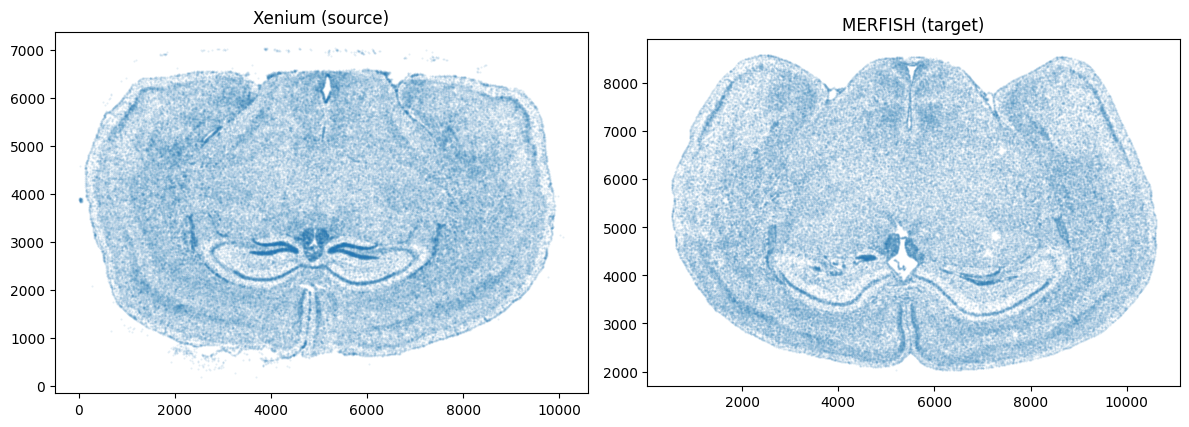

In [11]:
fig, axes = plt.subplots(1, 2)
for ax, ad_obj, title in [
    (axes[0], adata_xenium, "Xenium (source)"),
    (axes[1], adata_merfish, "MERFISH (target)"),
]:
    c = ad_obj.obsm["spatial"]
    ax.scatter(c[:, 0], c[:, 1], s=0.3, alpha=0.1)
    ax.set_aspect("equal")
    ax.set_title(title)
fig.tight_layout()

## Align with binned OT

In [12]:
sq.experimental.tl.align(
    adata_xenium,
    adata_merfish,
    method="optimal_transport",
    n_bins=100,
    verbose=True,
    solve_kwargs={"epsilon": 5e-4},
)

[ott-binned] Original: 130870 source + 120186 target = 251056 cells
[ott-binned] Binned:   7633 source bins (grid 100x100) + 8405 target bins (grid 100x100)
[ott-binned] Solving Sinkhorn on binned centroids ...
[ott] PointCloud: {'epsilon': 0.0005, 'scale_cost': 'mean'}
[ott] solve:      (defaults)
[ott] Sinkhorn:   (defaults)
[ott] cost matrix: mean=1.0000  shape=(7633, 8405)  epsilon=0.000500
[ott] converged=False  iterations=2000
[ott-binned] Computing transformation (mode='warp') ...


/Users/selman/projects/squidpy/src/squidpy/experimental/tl/_align.py:1362: UserWarning: Sinkhorn did not converge in 2000 iterations. Consider increasing max_iterations or epsilon.
  return _align_points_ot_binned(


[ott-binned] Aligned coordinates stored in obsm['spatial_aligned']


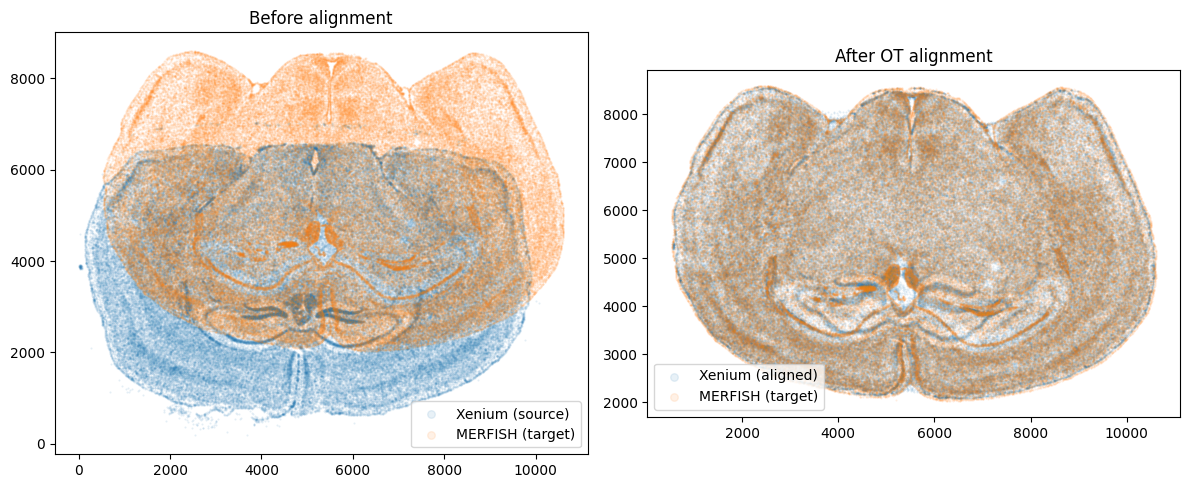

In [13]:
aligned = adata_xenium.obsm["spatial_aligned"]
merfish_coords = adata_merfish.obsm["spatial"]

fig, axes = plt.subplots(1, 2)
axes[0].scatter(adata_xenium.obsm["spatial"][:, 0], adata_xenium.obsm["spatial"][:, 1],
                s=0.3, alpha=0.1, label="Xenium (source)")
axes[0].scatter(merfish_coords[:, 0], merfish_coords[:, 1],
                s=0.3, alpha=0.1, label="MERFISH (target)")
axes[0].legend(markerscale=10)
axes[0].set_aspect("equal")
axes[0].set_title("Before alignment")

axes[1].scatter(aligned[:, 0], aligned[:, 1],
                s=0.3, alpha=0.1, label="Xenium (aligned)")
axes[1].scatter(merfish_coords[:, 0], merfish_coords[:, 1],
                s=0.3, alpha=0.1, label="MERFISH (target)")
axes[1].legend(markerscale=10)
axes[1].set_aspect("equal")
axes[1].set_title("After OT alignment")
fig.tight_layout()

/var/folders/xy/w8sj_5197yg42f3c2txh8gww0000gn/T/ipykernel_91419/4248818794.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend(markerscale=10)


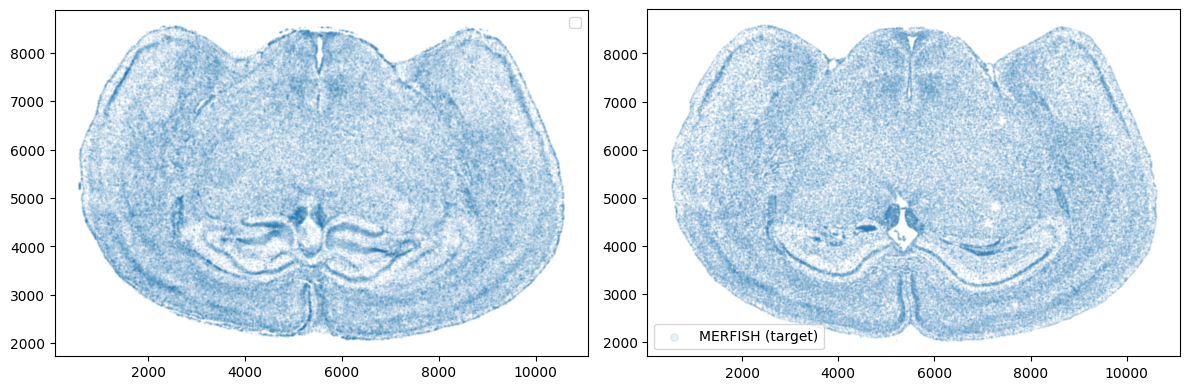

In [17]:
aligned = adata_xenium.obsm["spatial_aligned"]
merfish_coords = adata_merfish.obsm["spatial"]

fig, axes = plt.subplots(1, 2)

axes[0].legend(markerscale=10)
axes[0].set_aspect("equal")

axes[0].scatter(aligned[:, 0], aligned[:, 1],
                s=0.3, alpha=0.1, label="Xenium (aligned)")
axes[1].scatter(merfish_coords[:, 0], merfish_coords[:, 1],
                s=0.3, alpha=0.1, label="MERFISH (target)")
axes[1].legend(markerscale=10)
axes[1].set_aspect("equal")
fig.tight_layout()

## Score the alignment

| Metric | Range | Meaning |
|---|---|---|
| **coverage** | 0--1 | Fraction of target cells with a source neighbor within `radius` |
| **knn_mixing** | 0--1 | How well the two clouds intermix (1 = perfectly mixed) |
| **expr_knn_corr** | -1--1 | Median Pearson correlation between source cells and their target kNN expression |
| **expr_knn_cosine** | 0--1 | Same but with cosine similarity |
| **label_transfer_accuracy** | 0--1 | Majority-vote label from target kNN matches source's own label |

Note: `label_transfer_accuracy` requires both datasets to share a common
cell-type annotation scheme (e.g. both mapped to the Allen Brain Cell Type
taxonomy). Here the MERFISH and Xenium clusters were computed independently
(1,630 vs 45 clusters with different meanings), so we skip `label_key`.

In [19]:
scores = sq.experimental.tl.score_alignment(
    adata_xenium,
    adata_merfish,
    k=10,
)

[score_alignment] Alignment quality metrics:
  n_source:            130870
  n_target:            120186
  radius_used:         12.2347
  coverage:            0.7810
  mean_nn_dist:        9.3802
  median_nn_dist:      8.2766
  knn_mixing (k=10):   0.5253
  expr_knn_corr:       0.4883
  expr_knn_cosine:     0.5524


,score
metric,
coverage,0.780981
knn_mixing,0.525297
expr_knn_corr,0.488293
expr_knn_cosine,0.552369


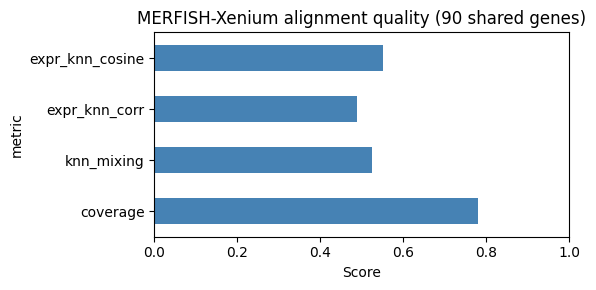

In [20]:
import pandas as pd

keys = ["coverage", "knn_mixing", "expr_knn_corr", "expr_knn_cosine"]
df = pd.DataFrame([{"metric": k, "score": scores[k]} for k in keys]).set_index("metric")

fig, ax = plt.subplots(figsize=(6, 3))
df["score"].plot.barh(ax=ax, color="steelblue")
ax.set_xlim(0, 1)
ax.set_xlabel("Score")
ax.set_title("MERFISH-Xenium alignment quality (90 shared genes)")
fig.tight_layout()

df